In [ ]:
# ClinicalBERT Extension: Sickle Cell Clinical NLP Risk Classification

## Overview

This notebook extends the main clinical NLP project by applying Bio_ClinicalBERT embeddings to the sickle cell emergency department notes. The aim is to compare a transformer-based clinical language representation with the traditional machine learning and LSTM approaches used in the main notebook.

The workflow reuses the same clinical feature engineering approach: structured variables, patient history features, laboratory changes, and selected clinical indicators are combined with text-derived representations.

## Computational Note

ClinicalBERT is more computationally expensive than the traditional and LSTM models. To keep the experiment feasible, this notebook uses a random subset of 10,000 training visits and 3,000 test visits for the ClinicalBERT experiments. 


import pandas as pd
import numpy as np
import re

# import kagglehub
# Download latest version
#path = kagglehub.dataset_download("jadeacevedo/sickle-cell-clinical-notes")

#print("Path to dataset files:", path)

#Reading in data
df = pd.read_csv('sickle_cell_clinical_notes.csv')
df.head()

## Preprocessing and Feature Engineering


In [2]:
# 1.Cleaning text with but keeping numbers
def clean_text_with_digits(text: str) -> str:
    if pd.isna(text):
        return ""
    text = text.lower()
    #keep Letters, digits, and whitespace; replace everything else with a space
    text = re.sub(r'[^a-z0-9\s]', ' ', text).strip()
    return text

df["clean_notes_v2"] = df["clinical_note"].apply(clean_text_with_digits)


# Extracting agefrom the note clinical notes
def extract_age_from_note(text: str):
    """
    Extracts the patient's age in years from the clinical note text,
    by finding patterns like '45-year-old' or '45 year old'.
    """
    if pd.isna(text):
        return np.nan
    #Lower case for easier matching
    t = text.lower()

    #looking for patterns like '45-year-old' or '45 year old'
    m = re.search(r'(\d+)\s*[- ]?\s*year[- ]old', t)
    if m:
        try:
            return int(m.group(1))
        except ValueError:
            return np.nan
    return np.nan        



# 2. Temporal / Patient history

#Parsing dates
df["visit_dt"] = pd.to_datetime(df["visit_datetime"], format="%m/%d/%y", errors = "coerce")
df["dob_dt"] = pd.to_datetime(df["dob"], format="%m/%d/%y", errors = "coerce")
df["diagnosis_dt"] = pd.to_datetime(df["diagnosis_date"], format="%m/%d/%y", errors = "coerce")

#Age and years since diagnosis (at this visit)
df["age_years"] = df["clinical_note"].apply(extract_age_from_note)
df["years_since_diagnosis"] = (
    (df["visit_dt"] - df["diagnosis_dt"]).dt.days / 365.25
).round(1)

#Sort by patience and time so "previous" makes sense
df = df.sort_values(["patient_id", "visit_dt"])

g = df.groupby("patient_id", group_keys=False)

#Previous visit date and time gap
df["prev_visit_dt"] = g["visit_dt"].shift(1)
df["days_since_last_visit"] = (df["visit_dt"] - df["prev_visit_dt"]).dt.days

#Number of previous visits for this patient
df["num_prev_visits"] = g.cumcount()

#Binary admitted label for history
df["admitted_bin"] = (df["admitted"] == "Yes").astype(int)

#Number of previous admissions for this patient
df["num_prev_admissions"] = g["admitted_bin"].cumsum().shift(1).fillna(0)

# Previous labs and changes since last visit
df["prev_hemoglobin"] = g["hemoglobin"].shift(1)
df["prev_oxygen_saturation"] = g["oxygen_saturation"].shift(1)

df["delta_hemoglobin"] = df["hemoglobin"] - df["prev_hemoglobin"]
df["delta_oxygen_saturation"] = (
    df["oxygen_saturation"] - df["prev_oxygen_saturation"]
)

#3. Features Extracted from notes

#Symptom duration in days (e.g. "2-day" or "2 day")
def extract_duration_days(text: str):
    if pd.isna(text):
        return np.nan
    m= re.search(r"(\d+)\s*[- ]?\s*day", text.lower())
    if m:
        try:
            return int(m.group(1))
        except ValueError:
            return np.nan
    return np.nan

#df["symptom_duration_days"] = df["clinical_note"].apply(extract_duration_days)

#Genotype (HbSS, HbSC, HbSβ+, etc.)
def extract_genotype(text: str):
    if pd.isna(text):
        return np.nan
    #common genotype patterns
    for gt in ["HbSS", "HbSC", "HbSβ⁺", "HbSβ˚", "HbSβ0"]:
        if gt.lower() in text.lower():
            return gt
    #fallback: anything like (Hb...)
    m = re.search(r"\((hb[^)]+)\)", text, flags = re.IGNORECASE)
    if m:
        return m.group(1)
        
    return np.nan

df["genotype"] = df["clinical_note"]. apply(extract_genotype)

# Severity / Symptom Keywords
def has_keyword(text: str, keywords):
    if pd.isna(text):
        return 0
    lower = text.lower()
    return int(any(kw in lower for kw in keywords))

df["has_severe"] = df["clinical_note"].apply(
    lambda t: has_keyword(t, ["severe"])
)
df["has_mild"] = df["clinical_note"].apply(
    lambda t: has_keyword(t, ["mild"])
)
df["has_worsening"] = df["clinical_note"].apply(
    lambda t: has_keyword(t, ["worsening"])
)
df["has_shortness_of_breath"] = df["clinical_note"].apply(
    lambda t: has_keyword(t, ["shortness of breath", "sob"])
)



# 4. New Target: hig_risk visit

df["high_risk"] = (
   (df["hemoglobin"] < 8.0)
    | (df["oxygen_saturation"] < 90.0)
    | (df["pain_intensity"] >= 8)
).astype(int)

print("Original admitted rate:", df["admitted_bin"].mean())
print("High risk rate:", df["high_risk"].mean())
print("Rows:", len(df), "Patients:", df["patient_id"].nunique())

Original admitted rate: 0.500533219579823
High risk rate: 0.5951796949984003
Rows: 75016 Patients: 5000


## Modelling with Engineered Features
- Splitting the data by patient into train and test set
- Using TF-IDF on clean_notes_v2(text with numbers)
- Combining text features with the engineered numeric features
- Training and evaluating:


In [3]:
#importing libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, roc_auc_score 
from scipy.sparse import hstack
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### Patient-Level Train/Test Split


In [4]:
patients = df['patient_id'].unique()
train_p, test_p = train_test_split(patients, test_size=0.2, random_state = 42)

train_df = df[df['patient_id'].isin(train_p)].copy()
test_df = df[df['patient_id'].isin(test_p)].copy()
print('train rows:', len(train_df), 'Test row:', len(test_df))

train rows: 60029 Test row: 14987


### Interpretation
To avoid information leakage across repeated visits for the same patient, train-test split was done at patient level. First, unique patient_ids were randomly split into 80% train and 20% test, then all visits for those patients were assigned to the corresponding set. This resulted in 60,029 training visits and 14,987 test visits, with no patient overlapping between split.


### Defining Features


In [5]:
text_col = 'clinical_note'

numeric_features =[
    "years_since_diagnosis", "age_years",
    "num_prev_visits", "num_prev_admissions", "days_since_last_visit",
    "hemoglobin", "prev_hemoglobin", "delta_hemoglobin",
    "oxygen_saturation", "prev_oxygen_saturation", "delta_oxygen_saturation",
    "pain_intensity", 'has_severe', 'has_mild', 'has_worsening', 'has_shortness_of_breath'
]
# Fill Nans in numeric features
for col in numeric_features:
    train_df[col] = train_df[col].fillna(0)
    test_df[col] = test_df[col].fillna(0)


In [6]:
# importing needed libraries
import tensorflow as tf
from transformers import AutoTokenizer, TFAutoModel

### Preparing the ClinicalBERT Tokenizer and Inputs


In [8]:
model_name = "emilyalsentzer/Bio_ClinicalBERT"

tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = TFAutoModel.from_pretrained(model_name)

# Using raw clinical notes for BERT 
text_col_bert ="clinical_note"

x_train_text_bert = train_df[text_col_bert].astype(str).tolist()
x_test_text_bert = test_df[text_col_bert].astype(str).tolist()

max_len_bert = 128


train_encodings = tokenizer(x_train_text_bert, truncation=True, 
                            padding="max_length", max_length=max_len_bert,
                            return_tensors="tf",)

test_encodings = tokenizer(x_test_text_bert, truncation=True, 
                           padding="max_length", max_length=max_len_bert,
                          return_tensors="tf",)


# Numeric features as float32
x_train_num = train_df[numeric_features].astype("float32").values
x_test_num = test_df[numeric_features].astype("float32").values

#Original Target
y_train_adm = train_df['admitted_bin'].values
y_test_adm = test_df['admitted_bin'].values

#Engineered Target
y_train_hr = train_df['high_risk'].values
y_test_hr = test_df['high_risk'].values

Some layers from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT were not used when initializing TFBertModel: ['nsp___cls', 'mlm___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertModel were initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions without further training.


### ClinicalBERT Subset for Computational Efficiency


In [10]:
# subset size
n_train_sub = 10000
n_test_sub = 3000

rng = np.random.default_rng(42)
train_idx = rng.choice(len(train_df), size=n_train_sub, replace=False)
test_idx = rng.choice(len(test_df), size=n_test_sub, replace=False)

# Convert indices to TF tensors for tf.gather
train_idx_tf = tf.constant(train_idx, dtype=tf.int32)
test_idx_tf = tf.constant(test_idx, dtype=tf.int32)

#subset text encoding
train_encodings_sub = {"input_ids": tf.gather(train_encodings["input_ids"],  train_idx_tf),
                      "attention_mask": tf.gather(train_encodings["attention_mask"],  train_idx_tf),}

test_encodings_sub = {"input_ids": tf.gather(test_encodings["input_ids"],  test_idx_tf),
                      "attention_mask": tf.gather(test_encodings["attention_mask"],  test_idx_tf),}

# subset numeric and labels
x_train_num_sub = x_train_num[train_idx]
x_test_num_sub = x_test_num[test_idx]


y_train_adm_sub = y_train_adm[train_idx]
y_test_adm_sub = y_test_adm[test_idx]
y_train_hr_sub = y_train_hr[train_idx]
y_test_hr_sub = y_test_hr[test_idx]

def get_cls_embeddings_in_batches(bert_model, encodings, batch_size=16):
    """
    Compute CLS embeddings in batches to avoid OOM.
    encodings: dict with "input_ids" and "attention_mask" (tf.Tensors)
    Returns: numpy array of shape (N, hidden_size)
    """
    input_ids = encodings["input_ids"]
    attention_mask = encodings["attention_mask"]

    n = input_ids.shape[0]
    cls_list = []

    for start in range(0, n, batch_size):
        end = start + batch_size
        ids_batch = input_ids[start:end]
        mask_batch = attention_mask[start:end]

        # Forward pass through BERT
        outputs = bert_model(ids_batch, attention_mask=mask_batch)
        cls_batch = outputs.last_hidden_state[:, 0, :].numpy()
        cls_list.append(cls_batch)
        
    return np.vstack(cls_list)


# Getting train and test embeddings
x_train_bert_sub = get_cls_embeddings_in_batches(bert_model, train_encodings_sub, batch_size=8)
x_test_bert_sub = get_cls_embeddings_in_batches(bert_model, test_encodings_sub, batch_size=8)

print("BERT sub train embeddings:", x_train_bert_sub.shape)
print("BERT sub test embeddings:", x_test_bert_sub.shape)


BERT sub train embeddings: (10000, 768)
BERT sub test embeddings: (3000, 768)


### Building the ClinicalBERT + Numeric MLP Model


In [11]:
from tensorflow.keras.layers import Input, Dense, Dropout, Concatenate, BatchNormalization
from tensorflow.keras import Model
from tensorflow.keras.optimizers import Adam
#from sklearn.metrics import classification_report, roc_auc_score

# Sizes from the subset
num_bert_features = x_train_bert_sub.shape[1]
num_numeric_features = x_train_num_sub.shape[1]

def build_clinicalbert_mlp(num_bert_features, num_numeric_features):
    #BERT CLS embedding input
    bert_input = Input(shape=(num_bert_features,), name="bert_input")
    x = Dropout(0.3)(bert_input)

    # Numeric input 
    numeric_input = Input(shape=(num_numeric_features,), name="numeric_input")    
    n = Dense(32, activation="relu")(numeric_input)
    n = Dropout(0.3)(n)

    # Combine BERT and Numeric
    h = Concatenate()([x, n])
    h = Dense(64, activation="relu")(h)
    h = Dropout(0.3)(h)
    output = Dense(1, activation="sigmoid")(h)

    model = Model(inputs=[bert_input, numeric_input], outputs=output) 
    model.compile(optimizer=Adam(1e-4),
                 loss="binary_crossentropy", metrics=["accuracy"])
    return model

### Training ClinicalBERT-MLP: Admission Target


In [17]:
batch_size_bert = 32 
epochs_bert = 5

early_stop_bert = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=1,
                                                  restore_best_weights=True,)

print("ClinicalBERT MLP for admitted_bin (subset)")

bert_mlp_adm = build_clinicalbert_mlp(num_bert_features, num_numeric_features)

history_bert_adm = bert_mlp_adm.fit({"bert_input": x_train_bert_sub, "numeric_input": x_train_num_sub}, 
                                    y_train_adm_sub, validation_split=0.1,
                                   batch_size=batch_size_bert, epochs=epochs_bert,
                                   callbacks=[early_stop_bert],
                                   verbose=1,)

#Evaluation
y_proba_adm_bert = bert_mlp_adm.predict({"bert_input": x_test_bert_sub, "numeric_input": x_test_num_sub}).ravel()
y_pred_adm_bert = (y_proba_adm_bert >= 0.5).astype(int)

print("\nClinicalBert MLP - admitted_bin (subset)")
print(classification_report(y_test_adm_sub, y_pred_adm_bert)) 
print("ROC-AUC:", roc_auc_score(y_test_adm_sub, y_proba_adm_bert))

ClinicalBERT MLP for admitted_bin (subset)
Epoch 1/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5092 - loss: 1.7619 - val_accuracy: 0.5360 - val_loss: 0.7413
Epoch 2/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4964 - loss: 1.0651 - val_accuracy: 0.5220 - val_loss: 0.6969
Epoch 3/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4915 - loss: 0.8545 - val_accuracy: 0.4980 - val_loss: 0.6955
Epoch 4/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5058 - loss: 0.7562 - val_accuracy: 0.4910 - val_loss: 0.6956
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

ClinicalBert MLP - admitted_bin (subset)
              precision    recall  f1-score   support

           0       0.48      0.77      0.59      1466
           1       0.49      0.22      0.30      1534

    accuracy                           0.49      3000
   macro avg       0.49      0.49      0.45      3000
weighted avg       0.49      0.49      0.44      3000

ROC-AUC: 0.48586540462566546


### Interpretation
A much smaller subset, 10,000 training and 3,000 test visits, was chosen to reduce computational and memory burden when applying the ClinicalBERT to the full set. On the subset used for the ClinicalBERT, the ClinicalBERT plus MLP (multi-layer perceptron) model achieved 0.49 accuracy and ROC-AUC almost 0.49 for the admitted vs not admitted task. This subset is still large enough to provide a stable estimate of performance, and the random guessing results confirm that even rich contextual embeddings from clinicalBERT do not uncover a meaningful predictive signal for the admission label in this synthetic dataset.


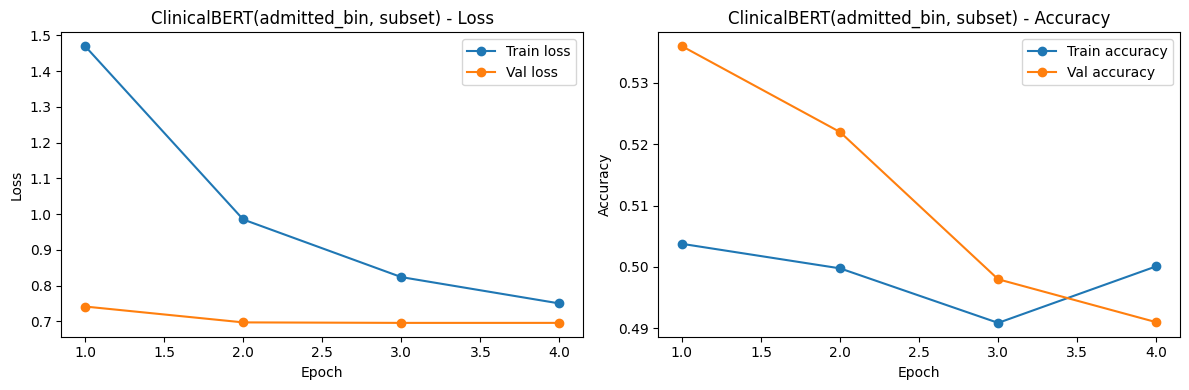

In [18]:
import matplotlib.pyplot as plt

def plot_training_curves(history, title_prefix = "ClinicalBERT MLP (subset)"):
    # Extract metrics from history
    train_loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    train_acc = history.history.get("accuracy")
    val_acc = history.history.get("val_accuracy")
    epochs_range = range(1, len(train_loss) + 1)

    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_loss, marker="o", label="Train loss")
    plt.plot(epochs_range, val_loss, marker="o", label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} - Loss")
    plt.legend()

    # Accuracy
    if train_acc is not None and val_acc is not None:
        plt.subplot(1, 2, 2)
        plt.plot(epochs_range, train_acc, marker="o", label="Train accuracy")
        plt.plot(epochs_range, val_acc, marker="o", label="Val accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title(f"{title_prefix} - Accuracy")
        plt.legend()

    plt.tight_layout()
    plt.show()

# Plotting for admitted_bin LSTM
plot_training_curves(history_bert_adm, title_prefix="ClinicalBERT(admitted_bin, subset)")

### Interpretation
On the admitted_bin task with the ClinicalBERT-MLP, training loss goes down, but validation loss stays around 0.69 and both train and validation accuracy hover near 50%, still a random guessing performance.


### Training ClinicalBERT-MLP: High-Risk Target


In [29]:
batch_size_bert = 32 
epochs_bert = 5

early_stop_bert = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=1,
                                                  restore_best_weights=True,)

print("ClinicalBERT MLP for high_risk (subset)")

bert_mlp_hr = build_clinicalbert_mlp(num_bert_features, num_numeric_features)

history_bert_hr = bert_mlp_hr.fit({"bert_input": x_train_bert_sub, "numeric_input": x_train_num_sub}, 
                                    y_train_hr_sub, validation_split=0.1,
                                   batch_size=batch_size_bert, epochs=epochs_bert,
                                   callbacks=[early_stop_bert],
                                   verbose=1,)

#Evaluation
y_proba_hr_bert = bert_mlp_hr.predict({"bert_input": x_test_bert_sub, "numeric_input": x_test_num_sub}).ravel()
y_pred_hr_bert = (y_proba_hr_bert >= 0.5).astype(int)

print("\nClinicalBert MLP - high_risk (subset)")
print(classification_report(y_test_hr_sub, y_pred_hr_bert)) 
print("ROC-AUC:", roc_auc_score(y_test_hr_sub, y_proba_hr_bert))

ClinicalBERT MLP for high_risk (subset)
Epoch 1/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5256 - loss: 1.8392 - val_accuracy: 0.5490 - val_loss: 0.7309
Epoch 2/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5246 - loss: 1.1080 - val_accuracy: 0.5750 - val_loss: 0.7000
Epoch 3/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5257 - loss: 0.8632 - val_accuracy: 0.5670 - val_loss: 0.6842
Epoch 4/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5446 - loss: 0.7586 - val_accuracy: 0.5620 - val_loss: 0.6832
Epoch 5/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5476 - loss: 0.7284 - val_accuracy: 0.5990 - val_loss: 0.6758
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

ClinicalBert MLP - high_risk (subset)
              precision    recall  f1-score   support

           0       0.56      0.02      0.03      1140
           1       0.62      0.99      0.76      1860

    accuracy                           0.62      3000
   macro avg       0.59      

### Interpretation
The ClinicalBERT-MLP model trained on the high_risk subset demonstrates modest improvement in validation accuracy across epochs, reaching 59.9%. However, performance remains suboptimal, with ROC-AUC at 0.566, indicating limited discriminative ability. The classification report reveals severe class imbalance effects, as the model heavily favors the positive class (recall = 0.99) while failing to capture the negative class (recall = 0.02), resulting in poor macro-level metrics


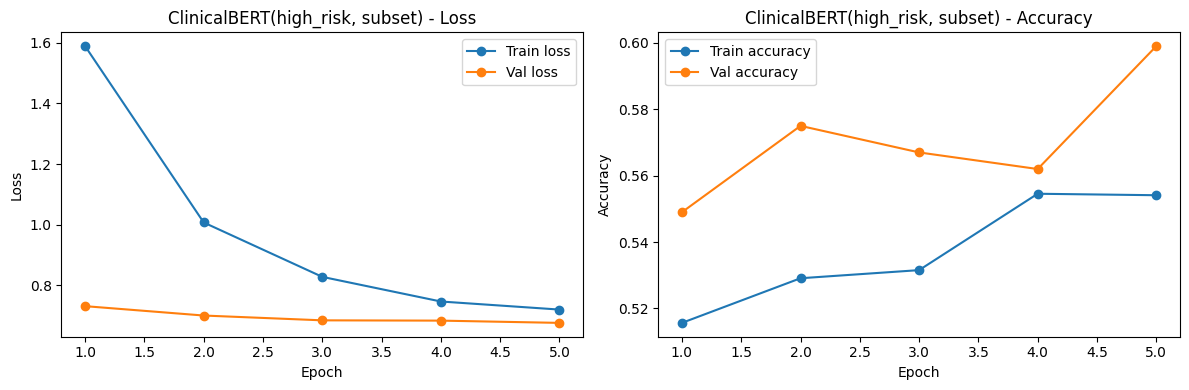

In [30]:
# Plotting for high_risk ClinicalBERT MLP
plot_training_curves(history_bert_hr, title_prefix="ClinicalBERT(high_risk, subset)")

### Interpretation
From the training curves, ClinicalBERT plus MLP on the high_risk subset is learning something, but not a strong classifier. Both train and validation  loss steadily decreases, and validation accuracy hovers around 0.60, which almost matches the test accuracy (0.62). so the model is consistently a bit better than random, but nowhere near the performance of the LSTM on the full dataset (almost 0.90 accuracy, and AUC around 0.97). Combined with the confussion matrix (very high recall for high_risk, very low recall for non-high-risk), this suggests the ClinicalBERT subset model picks up a weak signal and does so by mostly defaulting to the high-risk class.

### ROC Curves for Both Targets


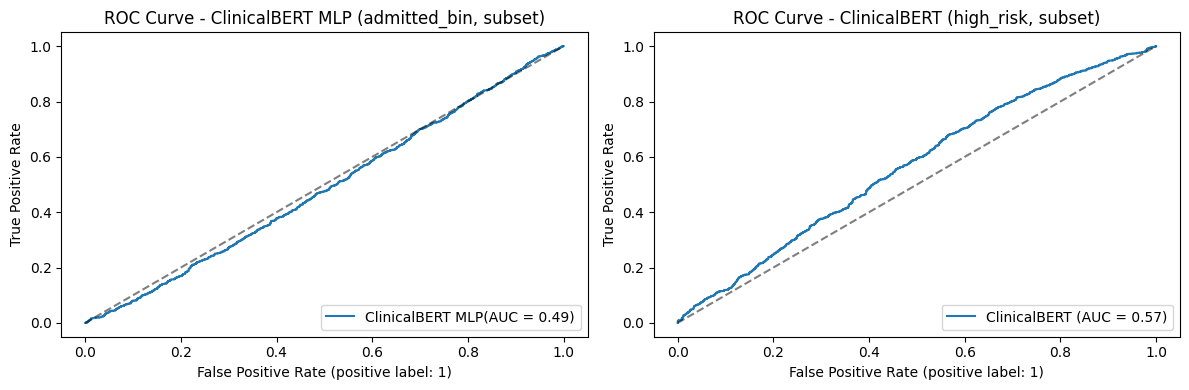

AUC (admitted_bin, ClinicalBERT MLP subset): 0.48586540462566546
AUC (high_risk, ClinicalBERT MLP subset): 0.5660733823806829


In [31]:
from sklearn.metrics import roc_curve, roc_auc_score

#AUC values
auc_adm_bert = roc_auc_score(y_test_adm_sub, y_proba_adm_bert)
auc_hr_bert = roc_auc_score(y_test_hr_sub, y_proba_hr_bert)

# ROC points
fpr_adm_bert, tpr_adm_bert, _ = roc_curve(y_test_adm_sub, y_proba_adm_bert)
fpr_hr_bert, tpr_hr_bert, _ = roc_curve(y_test_hr_sub, y_proba_hr_bert)

plt.figure(figsize=(12, 4))

# admitted_bin
plt.subplot(1, 2, 1)
plt.plot(fpr_adm_bert, tpr_adm_bert, label=f"ClinicalBERT MLP(AUC = {auc_adm_bert:.2f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate (positive label: 1)")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ClinicalBERT MLP (admitted_bin, subset)")
plt.legend(loc="lower right")

# high_risk
plt.subplot(1, 2, 2)
plt.plot(fpr_hr_bert, tpr_hr_bert, label=f"ClinicalBERT (AUC = {auc_hr_bert:.2f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate (positive label: 1)")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ClinicalBERT (high_risk, subset)")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

print("AUC (admitted_bin, ClinicalBERT MLP subset):", auc_adm_bert)
print("AUC (high_risk, ClinicalBERT MLP subset):", auc_hr_bert)

### Interpretation
On the ClinicalBERT subset, the ROC curves again mirror the main findings from the other models. For admitted_bin, the ClinicalBERT plus MLP ROC curve lies almost exactly on the diagonal (AUC almost 0.49), indicating performance at pure chance level even with contextual embeddings. For high_risk, the curve rises above the diagonal (AUC almost 0.57), showing a little ability to separate high_risk from non-high-risk visits. However, this remains far below the very strong performance achieved by the hybrid LSTM on the full dataset.


## Refined ClinicalBERT + Numeric MLP Model
Adding:
- Deeper wider MLP head
- BatchNormalisation
- L2 regularisation
- Refined dropout
- Class weighting


In [32]:
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight

# Sizes from the subset
num_bert_features = x_train_bert_sub.shape[1]
num_numeric_features = x_train_num_sub.shape[1]

def build_clinicalbert_mlp_refined(num_bert_features, num_numeric_features,
                                  l2_reg=1e-4, dropout_bert=0.4,
                                  dropout_num=0.3, dropout_head=0.4,):
    #BERT CLS embedding input
    bert_input = Input(shape=(num_bert_features,), name="bert_input")
    x = Dense(256, activation="relu", kernel_regularizer=l2(l2_reg))(bert_input)
    x = BatchNormalization()(x)
    x = Dropout(dropout_bert)(x)

    # Numeric input 
    numeric_input = Input(shape=(num_numeric_features,), name="numeric_input")    
    n = Dense(64, activation="relu", kernel_regularizer=l2(l2_reg))(numeric_input)
    n = BatchNormalization()(n)
    n = Dropout(dropout_num)(n)

    # Combine BERT and Numeric
    h = Concatenate()([x, n])
    h = Dense(128, activation="relu", kernel_regularizer=l2(l2_reg))(h)
    h = BatchNormalization()(h)
    h = Dropout(dropout_head)(h)
    h = Dense(64, activation="relu", kernel_regularizer=l2(l2_reg))(h)
    
    output = Dense(1, activation="sigmoid", name="output")(h)

    model = Model(inputs=[bert_input, numeric_input], outputs=output) 
    model.compile(optimizer=Adam(1e-4),
                 loss="binary_crossentropy", metrics=["accuracy"])
    return model

### Refined ClinicalBERT-MLP: Admission Target


In [34]:
batch_size_bert_ref = 32 
epochs_bert_ref = 8

early_stop_bert_ref = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=2,
                                                  restore_best_weights=True,)

print("Refined ClinicalBERT MLP for admitted_bin (subset)")

bert_mlp_adm_ref = build_clinicalbert_mlp_refined(num_bert_features, num_numeric_features)

history_bert_adm_ref = bert_mlp_adm_ref.fit({"bert_input": x_train_bert_sub, "numeric_input": x_train_num_sub}, 
                                    y_train_adm_sub, validation_split=0.1,
                                   batch_size=batch_size_bert_ref, epochs=epochs_bert_ref,
                                   callbacks=[early_stop_bert_ref],
                                   verbose=1,)

#Evaluation
y_proba_adm_bert_ref = bert_mlp_adm_ref.predict({"bert_input": x_test_bert_sub, "numeric_input": x_test_num_sub}).ravel()
y_pred_adm_bert_ref = (y_proba_adm_bert_ref >= 0.5).astype(int)

print("\nRefined ClinicalBert MLP - admitted_bin (subset)")
print(classification_report(y_test_adm_sub, y_pred_adm_bert_ref)) 
print("ROC-AUC:", roc_auc_score(y_test_adm_sub, y_proba_adm_bert_ref))

Refined ClinicalBERT MLP for admitted_bin (subset)
Epoch 1/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4979 - loss: 0.8780 - val_accuracy: 0.5270 - val_loss: 0.7507
Epoch 2/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5069 - loss: 0.8171 - val_accuracy: 0.5220 - val_loss: 0.7564
Epoch 3/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4967 - loss: 0.7981 - val_accuracy: 0.5200 - val_loss: 0.7494
Epoch 4/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5033 - loss: 0.7872 - val_accuracy: 0.5260 - val_loss: 0.7448
Epoch 5/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5021 - loss: 0.7794 - val_accuracy: 0.5210 - val_loss: 0.7463
Epoch 6/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5084 - loss: 0.7707 - val_accuracy: 0.5420 - val_loss: 0.7406
Epoch 7/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4971 - loss: 0.7764 - val_accuracy: 0.5400 - val_loss: 0.7403
Epoch 8/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accurac

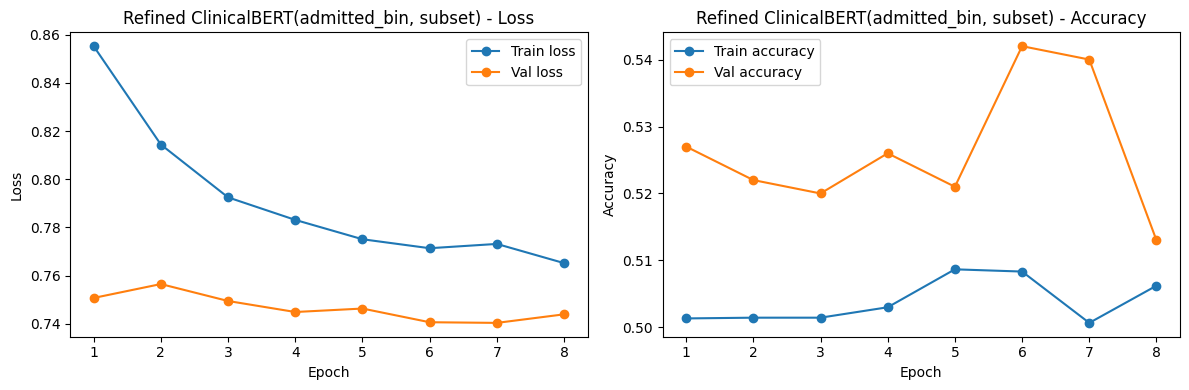

In [35]:
# Plotting for admitted_bin Refined ClinicalBERT MLP
plot_training_curves(history_bert_adm_ref, title_prefix="Refined ClinicalBERT(admitted_bin, subset)")

### Interpretation
For the ClinicalBERT MLP for admitted_bin, training loss decreases from around 0.86 to 0.76 and validation loss stays relatively flat around 0.74 to 0.76. The training accuracy hovers near 0.50 and validation accuracy flactuates between 0.52 and 0.54, with no consistent gap. This pattern indicates that, even with a deeper, regularised head on top of ClinicalBERt, the model cannot learn a meaningful decision boundary for admission status in this dataset.


### Refined ClinicalBERT-MLP: High-Risk Target


In [36]:
# Class weights
classes = np.array([0, 1])
class_weights_vals = compute_class_weight(class_weight="balanced", 
                                          classes=classes, y=y_train_hr_sub)
class_weights_hr = {int(c): w for c, w in zip(classes, class_weights_vals)}
print("Class weights (high_risk subset):", class_weights_hr)

# Training Refined ClinicalBERT MLP for high_risk
batch_size_bert_ref = 32 
epochs_bert_ref = 8

early_stop_bert_ref = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=2,
                                                  restore_best_weights=True,)

print("Refined ClinicalBERT MLP for high_risk (subset)")

bert_mlp_hr_ref = build_clinicalbert_mlp_refined(num_bert_features, num_numeric_features)

history_bert_hr_ref = bert_mlp_hr_ref.fit({"bert_input": x_train_bert_sub, "numeric_input": x_train_num_sub}, 
                                    y_train_hr_sub, validation_split=0.1,
                                   batch_size=batch_size_bert_ref, epochs=epochs_bert_ref,
                                   callbacks=[early_stop_bert_ref], class_weight=class_weights_hr,
                                   verbose=1,)

#Evaluation
y_proba_hr_bert_ref = bert_mlp_hr_ref.predict({"bert_input": x_test_bert_sub, "numeric_input": x_test_num_sub}).ravel()
y_pred_hr_bert_ref = (y_proba_hr_bert_ref >= 0.5).astype(int)

print("\nRefined ClinicalBert MLP - high_risk (subset)")
print(classification_report(y_test_hr_sub, y_pred_hr_bert_ref)) 
print("ROC-AUC:", roc_auc_score(y_test_hr_sub, y_proba_hr_bert_ref))

Class weights (high_risk subset): {0: np.float64(1.2534469791927803), 1: np.float64(0.8318083513558476)}
Refined ClinicalBERT MLP for high_risk (subset)
Epoch 1/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5191 - loss: 0.8490 - val_accuracy: 0.5130 - val_loss: 0.7477
Epoch 2/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5390 - loss: 0.7826 - val_accuracy: 0.5380 - val_loss: 0.7300
Epoch 3/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5478 - loss: 0.7534 - val_accuracy: 0.5580 - val_loss: 0.7203
Epoch 4/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5774 - loss: 0.7321 - val_accuracy: 0.6320 - val_loss: 0.6798
Epoch 5/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5925 - loss: 0.7131 - val_accuracy: 0.6590 - val_loss: 0.6639
Epoch 6/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6367 - loss: 0.6832 - val_accuracy: 0.6910 - val_loss: 0.6207
Epoch 7/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6578 - loss: 0.6672 

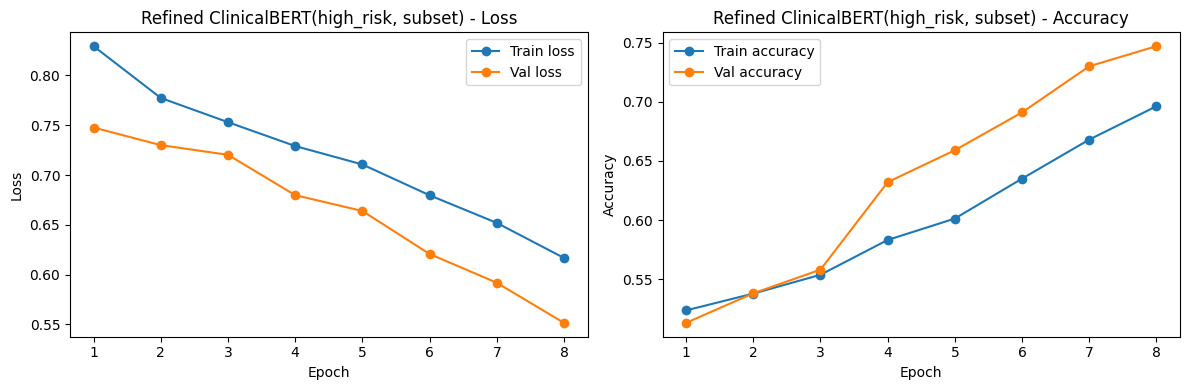

In [37]:
# Plotting for high_risk Refined ClinicalBERT MLP
plot_training_curves(history_bert_hr_ref, title_prefix="Refined ClinicalBERT(high_risk, subset)")

### Interpretation
For the high_risk, the refined ClinicalBERT-MLP on the subset reached 0.74 accuracy, with precision 0.62/0.85 and recall 0.81/0.70 for classes 0/1, and ROC-AUC almost 0.84. That was a big leap from the base ClinicalBERT model (AUC almost 0.56), showing that the deeper head, BatchNoramalization, L2 and class weighting really helped ClinicalBERT pick up the high-risk signal, even on reduced dataset.

Also, considering the training curves above, both tarining and validation loss steadily decrease while both accuracies climb, with validation accuracy ending around 0.74. The curves stay close together with no huge gap, which suggest the refined ClinicalBERT is really learning a stable high-risk signal on the subset rather than just overfitting noise.


### ROC Curves for Refined ClinicalBERT Models


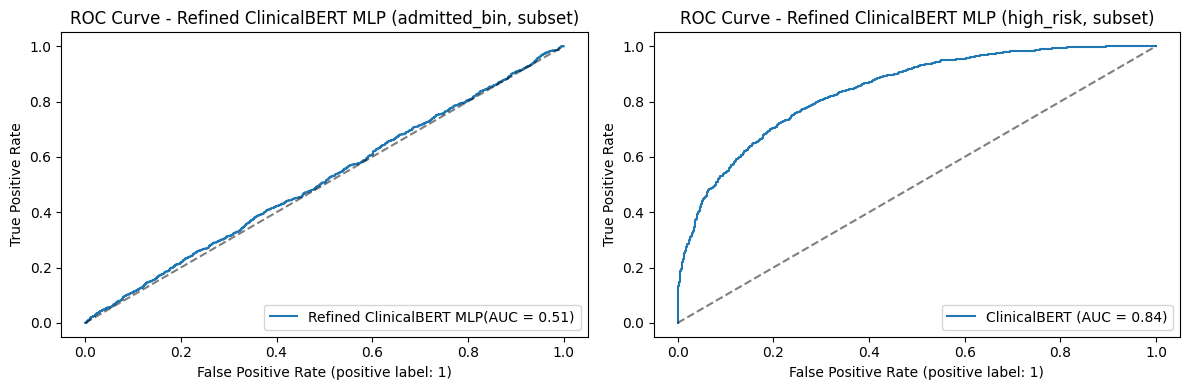

AUC (admitted_bin, ClinicalBERT MLP subset): 0.5121326779447574
AUC (high_risk, ClinicalBERT MLP subset): 0.8415020750801735


In [38]:
from sklearn.metrics import roc_curve, roc_auc_score

#AUC values
auc_adm_bert_ref = roc_auc_score(y_test_adm_sub, y_proba_adm_bert_ref)
auc_hr_bert_ref = roc_auc_score(y_test_hr_sub, y_proba_hr_bert_ref)

# ROC points
fpr_adm_ref, tpr_adm_ref, _ = roc_curve(y_test_adm_sub, y_proba_adm_bert_ref)
fpr_hr_ref, tpr_hr_ref, _ = roc_curve(y_test_hr_sub, y_proba_hr_bert_ref)

plt.figure(figsize=(12, 4))

# admitted_bin
plt.subplot(1, 2, 1)
plt.plot(fpr_adm_ref, tpr_adm_ref, label=f"Refined ClinicalBERT MLP(AUC = {auc_adm_bert_ref:.2f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate (positive label: 1)")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Refined ClinicalBERT MLP (admitted_bin, subset)")
plt.legend(loc="lower right")

# high_risk
plt.subplot(1, 2, 2)
plt.plot(fpr_hr_ref, tpr_hr_ref, label=f"ClinicalBERT (AUC = {auc_hr_bert_ref:.2f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate (positive label: 1)")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Refined ClinicalBERT MLP (high_risk, subset)")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

print("AUC (admitted_bin, ClinicalBERT MLP subset):", auc_adm_bert_ref)
print("AUC (high_risk, ClinicalBERT MLP subset):", auc_hr_bert_ref)

###### Comments:
For admitted_bin, the refined ClinicalBERT-MLP again sits almost exactly on the diagonal (AUC almost 0.51), confirming that even a deeper, regularised head cannot extract a predictive admission signal from this dataset.

In contrast, for high-risk the refined model reached an AUC of about 0.84, a clear improvement over the base ClinicalBERT MLP and consistent with the idea that the engineered high-risk label is much more strongly encoded in the notes plus numeric features.


#### Summary of Metrics


In [39]:
def collect_metrics(y_true, y_pred, y_score, model_name, label_name, data_split):
    return {
        "Data" : data_split,
        "Model": model_name,
        "Label": label_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, y_score),
    }

# CLINICALBERT ON SUBSET
rows_subset = []



# ClinicalBERT MLP (base) - subset
rows_subset.append(collect_metrics(y_test_adm_sub, y_pred_adm_bert,   y_proba_adm_bert,   "ClinicalBERT MLP (Base)",   "admitted_bin",  "subset"))
rows_subset.append(collect_metrics(y_test_hr_sub, y_pred_hr_bert,   y_proba_hr_bert,   "ClinicalBERT MLP (Base)",   "high_risk",  "subset"))
# ClinicalBERT Refined- subset
rows_subset.append(collect_metrics(y_test_adm_sub, y_pred_adm_bert_ref,   y_proba_adm_bert_ref,   "ClinicalBERT MLP (refined)",   "admitted_bin",  "subset"))
rows_subset.append(collect_metrics(y_test_hr_sub, y_pred_hr_bert_ref,   y_proba_hr_bert_ref,   "ClinicalBERT MLP (refined)",   "high_risk",  "subset"))

metrics_subset_df = pd.DataFrame(rows_subset).sort_values(["Label", "Model"])
display(metrics_subset_df.round(3))

,Data,Model,Label,Accuracy,Precision,Recall,ROC_AUC
0,subset,ClinicalBERT MLP (Base),admitted_bin,0.486,0.494,0.217,0.486
2,subset,ClinicalBERT MLP (refined),admitted_bin,0.514,0.519,0.653,0.512
1,subset,ClinicalBERT MLP (Base),high_risk,0.621,0.622,0.991,0.566
3,subset,ClinicalBERT MLP (refined),high_risk,0.739,0.855,0.698,0.842


#### Merging summary of ClinicalBERT metrics with Metrics of the traditional models and the LSTM


In [40]:
import os

# Loading existing summary (Traditional and LSTM)
summary_path_csv = "model_metrics_summary.csv"
summary_path_pkl = "model_metrics_summary.pkl"

if os.path.exists(summary_path_csv):
    base_df = pd.read_csv(summary_path_csv)
elif os.path.exists(summary_path_pkl):
    base_df = pd.read_pickle(summary_path_pkl)
else:
    raise FileNotFoundError("No model_metrics_summary.csv or .pkl found in this folder.")

# Tagging old file without 'Data Column' as 'full' (full dataset)
if "Data" not in base_df.columns:
    base_df["Data"] = "full"

# Making sure column oreder matches
cols = ["Data", "Model", "Label", "Accuracy", "Precision", "Recall", "ROC_AUC"]
base_df = base_df[cols]
metrics_subset_df = metrics_subset_df[cols]

# Merging (cocat) old summary with ClinicalBERT subset metrics
all_metrics_df = pd.concat([base_df, metrics_subset_df], ignore_index=True)
all_metrics_df = all_metrics_df.sort_values(["Label", "Model", "Data"])

display(all_metrics_df.round(3))

# Saving the udated summary
all_metrics_df.to_csv("model_metrics_summary_all.csv", index=False)

,Data,Model,Label,Accuracy,Precision,Recall,ROC_AUC
12,subset,ClinicalBERT MLP (Base),admitted_bin,0.486,0.494,0.217,0.486
13,subset,ClinicalBERT MLP (refined),admitted_bin,0.514,0.519,0.653,0.512
0,full,Hybrid LSTM (Base),admitted_bin,0.501,0.501,0.974,0.501
1,full,LSTM (Refined),admitted_bin,0.501,0.501,0.697,0.500
2,full,LinearSVM (Base),admitted_bin,0.499,0.500,0.543,0.495
3,full,LinearSVM (tuned),admitted_bin,0.499,0.500,0.540,0.496
4,full,LogReg (Base),admitted_bin,0.499,0.500,0.539,0.495
5,full,LogReg (tuned),admitted_bin,0.499,0.500,0.542,0.495
14,subset,ClinicalBERT MLP (Base),high_risk,0.621,0.622,0.991,0.566
15,subset,ClinicalBERT MLP (refined),high_risk,0.739,0.855,0.698,0.842


### Interpretation
Across all models, performances for admitted_bin label stayed essentially at random guess. Accuracy hovered around 0.50 and ROC-AUC around 0.49-0.51 for traditional models, LSTMs, and ClinicalBERT, indicating no usuable signal for admission in this synthetic dataset. In contrast, for high_risk, traditional text plus numeric models (logistic regression and linear SVM) on the full dataset performed well (accuracy around 0.81, ROC-AUC around 0.90), while the hybrid LSTM models were substantially stronger, with ROC-AUC up to around 1.00. On the 10,000/3,000 subset used for the ClinicalBERT, the ClinicalBERT plus MLP(multi-layer perceptron) models showed moderate performance for high_risk (base ROC-AUC around 0.57, refined 0.84), improving with the refined architecture but still not matching the full-data hybrid LSTM. Overall, the comparison reinforces a clear pattern, The engineered high_risk label contains a strong learnable signal, whereas admitted_bin does not.
